In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



EXPLANATORY DATA ANALYSIS (EDA)

In [2]:
casu_data=pd.read_excel('/home/johnkel/Desktop/Casaurina trial/causaurina_2006_data.xlsx')
casu_data.head()

,Block,T/NO,DBH (cm),HT (m),Spacing
0,I,1,D,D,1x1
1,I,2,6.5,7.5,1x1
2,I,3,D,D,1x1
3,I,4,D,D,1x1
4,I,5,D,D,1x1


In [3]:
# Rename columns to be easier to work with in code (no spaces/parentheses)
casu_data = casu_data.rename(columns={
    "T/NO": "TreeNo",
    "DBH (cm)": "DBH",
    "HT (m)": "Height"
})

In [4]:
casu_data.head()

,Block,TreeNo,DBH,Height,Spacing
0,I,1,D,D,1x1
1,I,2,6.5,7.5,1x1
2,I,3,D,D,1x1
3,I,4,D,D,1x1
4,I,5,D,D,1x1


In [5]:
casu_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Block    1190 non-null   str   
 1   TreeNo   1190 non-null   int64 
 2   DBH      1190 non-null   object
 3   Height   1190 non-null   object
 4   Spacing  1190 non-null   str   
dtypes: int64(1), object(2), str(2)
memory usage: 46.6+ KB


In [6]:
casu_data.shape

(1190, 5)

In [7]:
casu_data.groupby(["Block", "Spacing"]).size()

Block  Spacing
I      1x1        501
       2.5x2.5    100
II     1x1        496
       2.5x2.5     93
dtype: int64

In [8]:
print(casu_data.dtypes)

Block         str
TreeNo      int64
DBH        object
Height     object
Spacing       str
dtype: object


Explanatory data Analysis

In [9]:
#The .ne() method checks if the value is not equal to "D" (dead).

casu_data["Alive"] = (
    casu_data["DBH"].ne("D") &
    casu_data["Height"].ne("D")
)


#Creates a new column alive that is true if the tree is alive and false if the tree is dead. The .ne() method checks if the value is not equal to "D" (dead).
casu_data["Alive"].head(10)

0    False
1     True
2    False
3    False
4    False
5    False
6     True
7     True
8    False
9     True
Name: Alive, dtype: bool

In [10]:
print(casu_data.groupby(["Spacing", "Block"])["Alive"].mean()*100)  # Alive tree survival rate per group

Spacing  Block
1x1      I        63.872255
         II       60.080645
2.5x2.5  I        58.000000
         II       64.516129
Name: Alive, dtype: float64


In [11]:
survival = (
    casu_data.groupby(["Block", "Spacing"])
    .agg(
        Trees=("TreeNo", "size"),
        Alive=("Alive", "sum")
    )
    .reset_index()
)
survival.head(10)
#This creates a new dataframe that shows the number of trees per block together with the number of trees that survived in that same same block

,Block,Spacing,Trees,Alive
0,I,1x1,501,320
1,I,2.5x2.5,100,58
2,II,1x1,496,298
3,II,2.5x2.5,93,60


In [12]:
survival["Dead"] = survival["Trees"] - survival["Alive"]#Creates anew column in  the survived data frame that shows if a tree is dead


#This creates a new column that checks the percentage of alive trees per block
survival["Survival_%"] = (
    survival["Alive"] / survival["Trees"] * 100
)

survival


,Block,Spacing,Trees,Alive,Dead,Survival_%
0,I,1x1,501,320,181,63.872255
1,I,2.5x2.5,100,58,42,58.000000
2,II,1x1,496,298,198,60.080645
3,II,2.5x2.5,93,60,33,64.516129


Here we cannot conclude yet that one spacing is better since we see some differences in survival_% on both blocks

In [13]:
overall_survival = (
    casu_data.groupby("Spacing")
    .agg(
        Trees=("TreeNo", "size"),
        Alive=("Alive", "sum")
    )
    .reset_index()
)
overall_survival.head(10)
#creates a data frame that now shows the ovaerall survival stats of all tress per block

,Spacing,Trees,Alive
0,1x1,997,618
1,2.5x2.5,193,118


In [14]:
overall_survival["Dead"] = (
    overall_survival["Trees"] -
    overall_survival["Alive"]
)

overall_survival["Survival_%"] = (
    overall_survival["Alive"] /
    overall_survival["Trees"] * 100
)

overall_survival

,Spacing,Trees,Alive,Dead,Survival_%
0,1x1,997,618,379,61.985958
1,2.5x2.5,193,118,75,61.139896


There appears to be little difference in overall survival between the two spacing treatments.

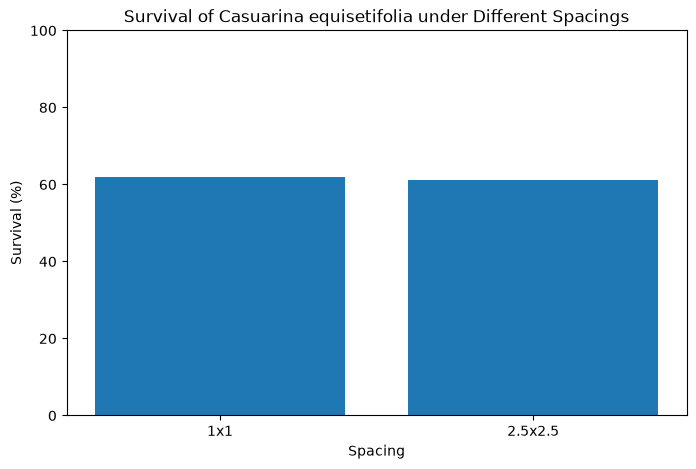

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    overall_survival["Spacing"],
    overall_survival["Survival_%"]
)

plt.xlabel("Spacing")
plt.ylabel("Survival (%)")
plt.title("Survival of Casuarina equisetifolia under Different Spacings")

plt.ylim(0, 100)
plt.show()

In [16]:
#creating a new columns that convert the DBH and Tree heights to numeric  formarts

casu_data["DBH_numeric"] = pd.to_numeric(
    casu_data["DBH"],
    errors="coerce"
)

casu_data["Height_numeric"] = pd.to_numeric(
    casu_data["Height"],
    errors="coerce"
)

In [17]:
casu_data.head(10)

,Block,TreeNo,DBH,Height,Spacing,Alive,DBH_numeric,Height_numeric
0,I,1,D,D,1x1,False,NaN,NaN
1,I,2,6.5,7.5,1x1,True,6.5,7.50
2,I,3,D,D,1x1,False,NaN,NaN
3,I,4,D,D,1x1,False,NaN,NaN
4,I,5,D,D,1x1,False,NaN,NaN
5,I,6,D,D,1x1,False,NaN,NaN
6,I,7,2.9,2.75,1x1,True,2.9,2.75
7,I,8,4.6,4.5,1x1,True,4.6,4.50
8,I,9,D,D,1x1,False,NaN,NaN
9,I,10,2.2,3,1x1,True,2.2,3.00
